# Profile Coherence as a Diagnostic Lens for Financial Asset Recommendation

## Abstract

Financial Asset Recommendation (FAR) literature optimises ranking quality (nDCG, Recall) and realised return (ROI) without exposing whether recommendations are profile-aligned in the regulatory sense required by MiFID II suitability. This work introduces **Profile Coherence at k (PC@k)** and asks four questions of the FAR-Trans dataset:

- **RQ1**: How prevalent and structural is profile-discordance in the observed Buy record?
- **RQ2**: Conditional on volatility, segment, and year, do profile-discordant transactions earn lower realised return?
- **RQ3**: Where do the published FAR-Trans baselines (Random Forest, LightGCN) sit on the PC@10 axis, by declared band?
- **RQ4**: Can a stratified profile-coherent LightGCN extension close the per-band coverage deficit, and at what cost on nDCG, Recall, and ROI?

## Setup

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

EDA_DIRECTORY = ROOT / "outputs/eda"
RQ2_DIRECTORY = ROOT / "outputs/analysis/transaction_return_regression/20260504_004849"
RQ3_DECOMP_DIRECTORY = ROOT / "outputs/analysis/baseline_decomposition/20260427_122215"
RQ3_PANEL_DIRECTORY = ROOT / "outputs/analysis/panel_regression/20260504_003145"
RQ4_RESULTS_DIRECTORY = ROOT / "outputs/results/evaluation/pc_lgcn/20260505_125105"
RQ4_BASELINE_DIRECTORY = ROOT / "outputs/results/evaluation/light_gcn/20260427_122215/eb788_00006"

RISK_BAND_NAMES = {0: "Conservative", 1: "Income", 2: "Balanced", 3: "Aggressive"}
BAND_COLOURS = {
    "Conservative": "#1f77b4",
    "Income": "#2ca02c",
    "Balanced": "#ff7f0e",
    "Aggressive": "#d62728",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.4,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

with open(EDA_DIRECTORY / "summary.json") as fh:
    eda_summary = json.load(fh)

## Profile Coherence Metric

The metric is constructed via the following steps:

### Pairwise discordance

- `src/utils/profile_coherence.py` puts customers and assets on the **same 4-point ordinal scale**: `Conservative=0, Income=1, Balanced=2, Aggressive=3`.
- **Customer band**:
    - Read from FAR-Trans's `riskLevel` column
    - The 4 declared strings map directly
    - The 4 regression-imputed `Predicted_*` strings get the same ordinal mapping with an `is_predicted` flag
    - Customers with `Not_Available` or missing `riskLevel` get `b_u = None` and are excluded from the metric
- **Asset band (hierarchical steps)**:
    1. Subcategory metadata first:
        - Mutual Funds subcategories: `Money Market -> Conservative`, `Bond/Bonds -> Income`, `Balanced -> Balanced`, `Equity/Large Cap -> Aggressive`
        - Bond subcategories: `Government -> Conservative`, `Corporate -> Income` (other bonds default to Income)
    2. Volatility-quartile fallback for stocks:
        - A trailing 252-day annualised log-return std is computed per ISIN
        - The stock-only distribution gives `(q1, q2, q3)` and each stock is bucketed accordingly
    3. Balanced default:
        - Assets that fall through both rules (typically stocks without enough history) get Balanced
- **Pairwise discordance** then is `d(u, i) = |b_u - b_i| ∈ {0, 1, 2, 3}`
- A recommendation is **profile-coherent** iff `d ≤ 1` (Note that the strict variant `d == 0` is reported only as a sensitivity row)

### Profile Coherence @k

- `src/utils/metrics.py` wraps the above into the `@k` aggregation:
    ```
    PC@k(u) = (1/k) · |{ i ∈ top_k(u) : d(u, i) ≤ 1 }|
    ```
- 3 implementation rules close the definition:
    1. **Truncation, not pad**: a recommender returning fewer than `k` items is scored on what it returned (`len(top_k)` replaces `k`)
    2. **Unclassifiable assets count as discordant**: an `asset_id` missing from the band lookup contributes 0 to `coherent_count` (rare given the Balanced default)
    3. **No-band customers contribute 0**: customers with `b_u = None` are excluded so the aggregate draws only on customers with a profile signal
- The aggregate **PC@k for a split** is the unweighted mean of per-customer PC@k across eligible customers in that split
- Headline numerics then average over the 69 splits

### Baseline Profile Coherence

- **Random baseline `pi(b)`** is computed directly from the asset-band distribution (`compute_random_baseline_per_band`):
    ```
    pi(b) = |{ i ∈ A : |b - b_i| ≤ 1 }| / |A|
    ```
- In other words, the closed-form expectation of PC@k under a uniformly random recommender per band
- For FAR-Trans the asset-band distribution `(190, 333, 105, 178)` over `(Conservative, Income, Balanced, Aggressive)` of 806 assets gives `pi = (0.65, 0.78, 0.76, 0.35)`

### Profile Coherence - Lift @k

- **PC-lift@k** divides per-user PC@k by the customer's band baseline: 
    ```
    PC-lift@k(u) = PC@k(u) / pi(b_u)
    ```
- Most assets in the dataset sit in Income/Balanced
- So if a recommender just shoves Income/Balanced funds at everyone, it scores well on raw PC@k for the majority of users (whose own band is Income or Balanced and who are within tolerance 1 of each other).
- PC-lift fixes this by dividing each user's PC@k by what a coin-flip recommender would get for that user's
band
- Lift = 1.0 implies the model matched random sampling
- Lift > 1.0 implies the model beats the band-conditional random rate

## RQ1: Profile-discordance is prevalent and structural

**Question.** How prevalent is profile-discordance in observed FAR-Trans Buy transactions, and is it customer-level trait or transaction-level noise?

**Setup.** Each Buy transaction `(u, i)` is annotated with a customer band `b_u` and an asset band `b_i` using the rules described above. Pairwise discordance is `d = |b_u - b_i|` and the transaction is profile-coherent under the default tolerance iff `d <= 1`.

In [2]:
discordance = eda_summary["transaction_discordance_summary"]
counts = discordance["discordance_counts"]
total = discordance["transactions_with_both_bands"]

distribution = pd.DataFrame(
    [
        {"d": int(k), "count": v, "share": v / total}
        for k, v in counts.items()
    ]
).sort_values("d")

distribution["label"] = distribution["d"].map(
    {0: "d=0 (exact match)", 1: "d=1 (within tolerance)", 2: "d=2", 3: "d=3"}
)

print(
    f"Total scoreable Buys:      {total:,}\n"
    f"Coherent (d<=1) share:     {discordance['fraction_coherent_default']:.1%}\n"
    f"Strict-coherent (d=0):     {discordance['fraction_coherent_strict']:.1%}\n"
    f"Mean profile discordance:  {discordance['mean_discordance']:.3f} bands"
)

distribution[["label", "count", "share"]].rename(columns={"label": "discordance"}).style.format({"count": "{:,}", "share": "{:.1%}"})

Total scoreable Buys:      228,241
Coherent (d<=1) share:     81.4%
Strict-coherent (d=0):     34.1%
Mean profile discordance:  0.874 bands


,discordance,count,share
0,d=0 (exact match),"77,925",34.1%
1,d=1 (within tolerance),"107,899",47.3%
2,d=2,"35,581",15.6%
3,d=3,"6,836",3.0%


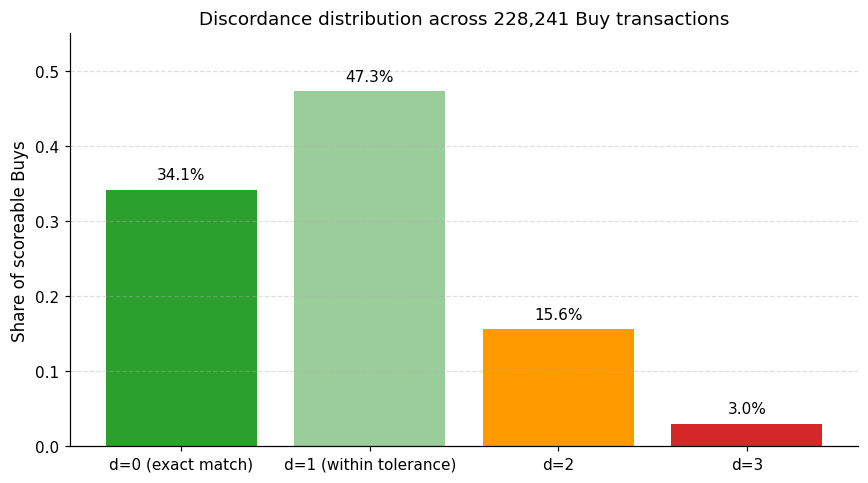

In [3]:
fig, ax = plt.subplots()
colours = ["#2ca02c", "#9bcd9b", "#ff9900", "#d62728"]
ax.bar(distribution["label"], distribution["share"], color=colours)
for x, value in enumerate(distribution["share"]):
    ax.text(x, value + 0.01, f"{value:.1%}", ha="center", va="bottom")
ax.set_ylim(0, 0.55)
ax.set_ylabel("Share of scoreable Buys")
ax.set_title(f"Discordance distribution across {total:,} Buy transactions")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

**Reading.** 81.4% of Buys are coherent under the default tolerance. The remaining 18.6% (42,417 Buys) violate the declared MiFID band by 2 or more steps; 3.0% are extreme `d=3` mismatches. Mean discordance is 0.87 bands, so the typical violation is a one-band miss, but the tail is heavy.

Fully coherent customers   (every Buy in tolerance): 64.4%
Fully discordant customers (every Buy out of tolerance): 17.2%
Majority-discordant share  (>50% of Buys discordant): 20.3%
Median discordant share    (50th-pct customer): 0.0%


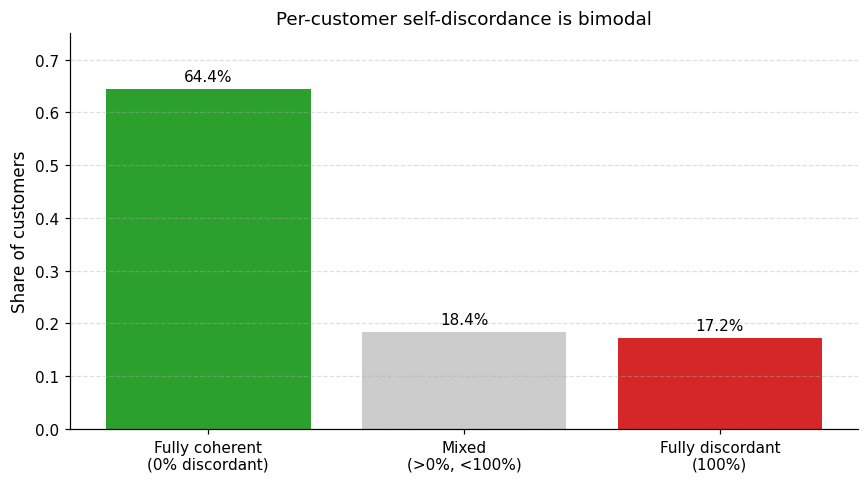

In [4]:
self_disc = eda_summary["customer_self_discordance_summary"]
print(
    f"Fully coherent customers   (every Buy in tolerance): {self_disc['fraction_fully_coherent']:.1%}\n"
    f"Fully discordant customers (every Buy out of tolerance): {self_disc['fraction_fully_discordant']:.1%}\n"
    f"Majority-discordant share  (>50% of Buys discordant): {self_disc['fraction_with_majority_discordance']:.1%}\n"
    f"Median discordant share    (50th-pct customer): {self_disc['median_discordant_share']:.1%}"
)

fig, ax = plt.subplots()
labels = ["Fully coherent\n(0% discordant)", "Mixed\n(>0%, <100%)", "Fully discordant\n(100%)"]
mixed = max(0.0, 1.0 - self_disc["fraction_fully_coherent"] - self_disc["fraction_fully_discordant"])
values = [self_disc["fraction_fully_coherent"], mixed, self_disc["fraction_fully_discordant"]]
bar_colours = ["#2ca02c", "#cccccc", "#d62728"]
ax.bar(labels, values, color=bar_colours)
for x, value in enumerate(values):
    ax.text(x, value + 0.01, f"{value:.1%}", ha="center", va="bottom")
ax.set_ylim(0, 0.75)
ax.set_ylabel("Share of customers")
ax.set_title("Per-customer self-discordance is bimodal")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

**Reading.** The per-customer distribution is strongly bimodal with most mass piled at the two extremes: 64.4% of customers are **fully coherent** (every Buy has `d <= 1`) and 17.2% are **fully discordant**(every Buy has `d >= 2`); only 18.4% sit strictly between. Profile-discordance is persistent within customers, not transaction-level noise.

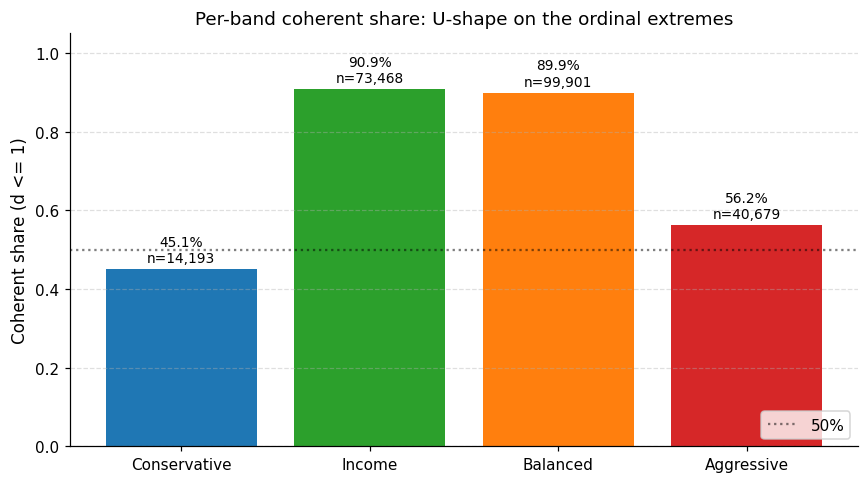

,band_label,transactions,coherent_share
2,Conservative,14193,45.1%
3,Income,73468,90.9%
1,Balanced,99901,89.9%
0,Aggressive,40679,56.2%


In [5]:
risk_level_counts = eda_summary["transaction_discordance_by_risk_level"]
band_rows = []
for band_label, by_d in risk_level_counts.items():
    total_band = sum(by_d.values())
    coherent_band = by_d.get("0", 0) + by_d.get("1", 0)
    band_rows.append({
        "band_label": band_label,
        "transactions": total_band,
        "coherent_share": coherent_band / total_band if total_band else 0,
    })
band_table = pd.DataFrame(band_rows)
band_order = ["Conservative", "Income", "Balanced", "Aggressive"]
band_table["band_label"] = pd.Categorical(band_table["band_label"], categories=band_order, ordered=True)
band_table = band_table.sort_values("band_label")

fig, ax = plt.subplots()
colours = [BAND_COLOURS[label] for label in band_table["band_label"]]
ax.bar(band_table["band_label"].astype(str), band_table["coherent_share"], color=colours)
for x, (count, share) in enumerate(zip(band_table["transactions"], band_table["coherent_share"])):
    ax.text(x, share + 0.01, f"{share:.1%}\nn={count:,}", ha="center", va="bottom", fontsize=9)
ax.axhline(0.5, linestyle=":", color="black", alpha=0.5, label="50%")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Coherent share (d <= 1)")
ax.set_title("Per-band coherent share: U-shape on the ordinal extremes")
ax.grid(axis="x", visible=False)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

band_table.assign(coherent_share=lambda d: d["coherent_share"].map("{:.1%}".format))

**Reading.** Discordance is concentrated on the two ordinal extremes. Conservative customers are coherent on only 45.1% of their Buys (the rest are reach-for-yield purchases of riskier assets), and Aggressive customers are coherent on 56.2% (regression-toward-the-centre into safer assets). The two centre bands (Income, Balanced) are roughly 90% coherent.

The U-shape is the strongest empirical motivation for treating profile alignment as a load-bearing recommender axis.

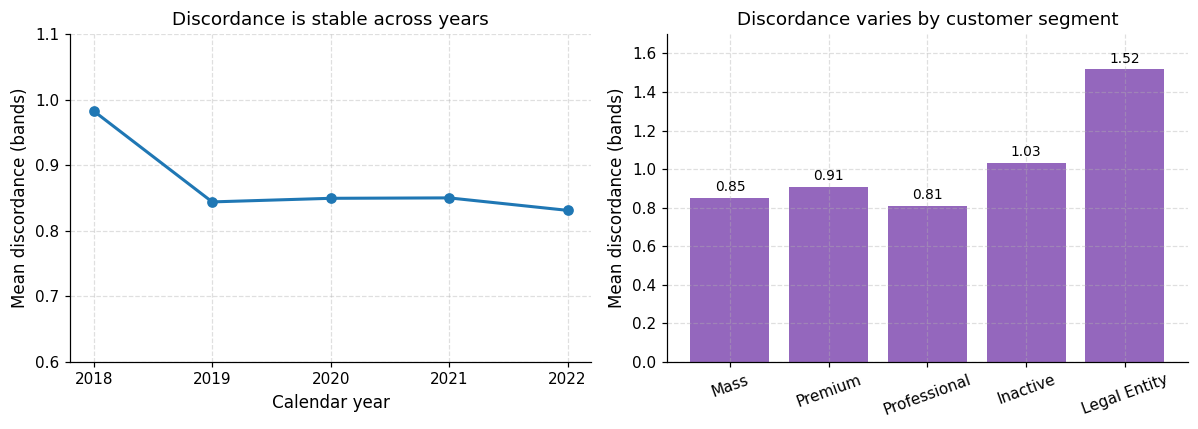

In [6]:
year_disc = eda_summary["mean_discordance_by_year"]
segment_disc = eda_summary["mean_discordance_by_segment"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

years = sorted(year_disc)
axes[0].plot(years, [year_disc[y] for y in years], marker="o", linewidth=2, color="#1f77b4")
axes[0].set_ylim(0.6, 1.1)
axes[0].set_ylabel("Mean discordance (bands)")
axes[0].set_xlabel("Calendar year")
axes[0].set_title("Discordance is stable across years")

segment_order = ["Mass", "Premium", "Professional", "Inactive", "Legal Entity"]
segments = [s for s in segment_order if s in segment_disc]
axes[1].bar(segments, [segment_disc[s] for s in segments], color="#9467bd")
for x, segment in enumerate(segments):
    axes[1].text(x, segment_disc[segment] + 0.02, f"{segment_disc[segment]:.2f}", ha="center", va="bottom", fontsize=9)
axes[1].set_ylim(0, 1.7)
axes[1].set_ylabel("Mean discordance (bands)")
axes[1].set_title("Discordance varies by customer segment")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

**RQ1 findings: Profile-discordance in FAR-Trans is**

- **Prevalent**: 18.6% of all scoreable Buys are profile-discordant (`d >= 2`).
- **Customer-level**: the per-customer discordance share is bimodal
(64.4% always-coherent, 17.2% always-discordant), so discordance is a
property of *who* the customer is, not a per-trade accident.
- **Structurally concentrated on the ordinal extremes**: edge bands
have far lower coherent share (Conservative 45.1%, Aggressive 56.2%)
than middle bands (Income 90.9%, Balanced 89.9%), driven by the
asymmetric tolerance window on the ordinal axis.
- **Stable across the macro window (2018-2022)**: mean discordance is
flat across years, so the pattern is not driven by a market regime or
a one-off product push.

**Takeaway**: discordance is a customer-level trait, not a transaction-level accident or a regime-specific spike.

## RQ2: Profile-coherent transactions earn higher realised return

**Question.** Conditional on asset volatility, customer segment, and year, do profile-discordant transactions earn lower realised 6-month return than profile-coherent ones?

**Setup.** Each Buy is joined to a 6-month-forward close price under a 7-day backward `merge_asof`, giving `realised_return = (end_price - start_price) / start_price`. The model is

```
realised_return ~ is_coherent + asset_volatility + C(customer_type) + C(year)
```

with cluster-robust SE clustered on `customerID`.

In [7]:
coefficients = pd.read_csv(RQ2_DIRECTORY / "coefficients.csv")
with open(RQ2_DIRECTORY / "summary.json") as fh:
    rq2_summary = json.load(fh)

coherent_mean = rq2_summary["mean_realised_return_coherent"]
discordant_mean = rq2_summary["mean_realised_return_discordant"]
raw_gap_pp = (coherent_mean - discordant_mean) * 100

print(
    f"Coherent share in panel:           {rq2_summary['coherent_share']:.3f}"
    f"     <- fraction of Buys in the regression panel with d<=1\n"
    f"Mean realised return (overall):    {rq2_summary['mean_realised_return_overall']:+.3%}"
    f"   <- 6-month forward return averaged across every Buy\n"
    f"Mean realised return (coherent):   {coherent_mean:+.3%}"
    f"   <- same average, restricted to coherent Buys (d<=1)\n"
    f"Mean realised return (discordant): {discordant_mean:+.3%}"
    f"   <- same average, restricted to discordant Buys (d>=2)\n"
    f"Raw slice gap (coh. - disc.):      {raw_gap_pp:+.2f} pp"
    f"      <- unconditional difference, before any controls"
)

display_terms = [
    "is_coherent",
    "asset_volatility",
    "C(year)[T.2020]",
    "C(year)[T.2022]",
    "Intercept",
]
term_explanations = {
    "is_coherent": "coherence premium after controlling for vol, segment, year",
    "asset_volatility": "return penalty per 1.0 unit of annualised vol (negative = low-vol won)",
    "C(year)[T.2020]": "calendar effect vs reference year (COVID rebound)",
    "C(year)[T.2022]": "calendar effect vs reference year (bond / rate-shock drawdown)",
    "Intercept": "fitted return at all-zero regressors (geometric anchor, not interpretable)",
}
filtered = coefficients[coefficients["term"].isin(display_terms)].copy()
filtered = filtered.set_index("term").reindex(display_terms).reset_index()


def fmt_p(p):
    if p < 1e-3:
        return f"{p:.1e}"
    return f"{p:.4f}"


filtered_display = filtered.assign(
    estimate=lambda d: d["estimate"].map("{:+.4f}".format),
    std_error=lambda d: d["std_error"].map("{:.4f}".format),
    ci=lambda d: d.apply(
        lambda r: f"[{r['ci_lower']:+.4f}, {r['ci_upper']:+.4f}]", axis=1
    ),
    p_value=lambda d: d["p_value"].map(fmt_p),
    meaning=lambda d: d["term"].map(term_explanations),
)
filtered_display[["term", "estimate", "std_error", "ci", "p_value", "meaning"]]


Coherent share in panel:           0.813     <- fraction of Buys in the regression panel with d<=1
Mean realised return (overall):    +3.614%   <- 6-month forward return averaged across every Buy
Mean realised return (coherent):   +4.232%   <- same average, restricted to coherent Buys (d<=1)
Mean realised return (discordant): +0.925%   <- same average, restricted to discordant Buys (d>=2)
Raw slice gap (coh. - disc.):      +3.31 pp      <- unconditional difference, before any controls


,term,estimate,std_error,ci,p_value,meaning
0,is_coherent,+0.0294,0.0040,"[+0.0215, +0.0372]",2.3e-13,"coherence premium after controlling for vol, s..."
1,asset_volatility,-0.1025,0.0165,"[-0.1349, -0.0701]",5.5e-10,return penalty per 1.0 unit of annualised vol ...
2,C(year)[T.2020],+0.2107,0.0061,"[+0.1986, +0.2227]",6.2e-259,calendar effect vs reference year (COVID rebound)
3,C(year)[T.2022],-0.0195,0.0045,"[-0.0283, -0.0107]",1.4e-05,calendar effect vs reference year (bond / rate...
4,Intercept,-0.0471,0.0141,"[-0.0746, -0.0195]",8.1e-04,fitted return at all-zero regressors (geometri...


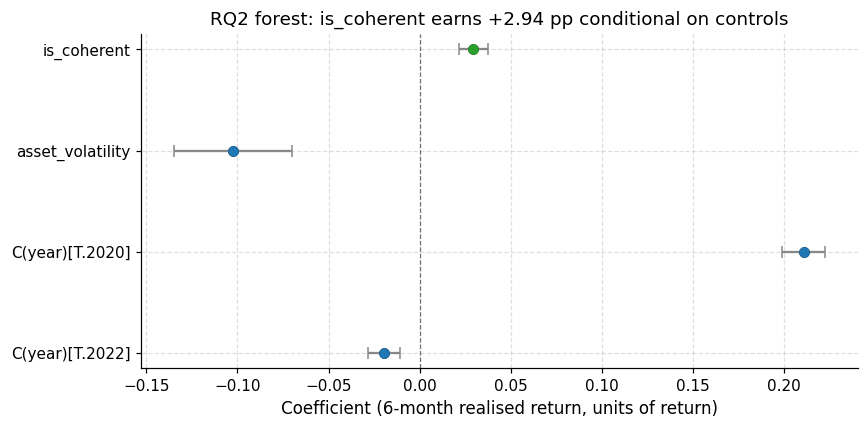

In [8]:
key_rows = coefficients[coefficients["term"].isin([
    "is_coherent", "asset_volatility",
    "C(year)[T.2020]", "C(year)[T.2022]",
])].copy()
order = ["is_coherent", "asset_volatility", "C(year)[T.2020]", "C(year)[T.2022]"]
key_rows = key_rows.set_index("term").reindex(order).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
positions = np.arange(len(key_rows))
estimates = key_rows["estimate"].to_numpy()
lower = estimates - key_rows["ci_lower"].to_numpy()
upper = key_rows["ci_upper"].to_numpy() - estimates
colour_pal = ["#2ca02c" if t == "is_coherent" else "#1f77b4" for t in key_rows["term"]]
ax.errorbar(estimates, positions, xerr=[lower, upper], fmt="o", capsize=4,
            ecolor="#888888", markerfacecolor=colour_pal[0], markeredgecolor="black")
for pos, est, term in zip(positions, estimates, key_rows["term"]):
    ax.scatter(est, pos, color="#2ca02c" if term == "is_coherent" else "#1f77b4", zorder=5)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_yticks(positions)
ax.set_yticklabels(key_rows["term"])
ax.set_xlabel("Coefficient (6-month realised return, units of return)")
ax.set_title("RQ2 forest: is_coherent earns +2.94 pp conditional on controls")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Reading.** Conditional on asset volatility, customer segment, and year, profile-coherent Buys earn **+2.94 percentage points** more 6-month realised return than profile-discordant ones (95% CI [+2.15, +3.72] pp, p < 1e-12). The raw slice gap is 3.31 pp; the controls absorb only ~0.4 pp, so the residual association is robust to observable confounders. The 2020 fixed effect (+21 pp) absorbs the post-COVID equity rally, the negative 2022 effect (-1.9 pp) absorbs the bond drawdown, and the volatility coefficient is negative as expected (more volatile assets earned lower 6-month forward returns over the sample window).

**RQ2 findings: Profile coherence is not a regulatory tax on the customer side**

- **Positively correlated with realised return**: profile-coherent Buys earn **+2.94 pp** more 6-month return than discordant ones, conditional on volatility, segment, and year (95% CI [+2.15, +3.72] pp, p < 1e-12).
- **Robust to observable confounders**: the raw slice gap is 3.31 pp; controls absorb only ~0.4 pp, so the residual is not a volatility/year/segment artefact.
- **Statistically tight**: under cluster-robust SE on `customerID` (which treats customers, not Buys, as independent units), the gap is still distinguishable from zero by many orders of magnitude.
- **Economically meaningful**: ~6 pp annualised on a 6-month horizon, large enough to matter on returns, not just on p-values.

**Takeaway**: FAR research has assumed that recommending profile-aligned assets would cost return. The customer data shows the opposite: customers earned **more** on profile-aligned Buys, not less. There is no return penalty to pay for staying inside the customer's declared risk band.


## RQ3: Both FAR-Trans baselines under-serve declared-band coherence

**Question.** Where do the FAR-Trans baselines (Random Forest, LightGCN) sit on the PC@10 axis, and does any baseline match or exceed the band-conditional random baseline `pi(b)` for every declared band?

**Setup.** Each baseline is tuned on its FAR-Trans primary metric (LightGCN: nDCG@10, Random Forest: ROI@10) over a grid of 8/12 trials respectively, evaluated on 69 monthly temporal splits between Aug 2019 and Apr 2025. The model panel regression `coherent_share ~ C(declared_band) * C(model) + C(split_index)` is fit with cluster-robust SE on `customer_id`; predicted PC@10 is reported at the median split (36).

In [9]:
main_results = pd.read_csv(RQ3_DECOMP_DIRECTORY / "main_results.csv")
display_columns = [
    "display_name", "best_trial_id", "primary_metric",
    "ndcg_at_k_mean", "roi_at_k_mean", "recall_at_k_mean",
    "profile_coherence_at_k_mean", "profile_coherence_lift_at_k_mean",
]
main_results_display = main_results[display_columns].rename(columns={
    "display_name": "Model",
    "best_trial_id": "Best trial",
    "primary_metric": "Primary metric",
    "ndcg_at_k_mean": "nDCG@10",
    "roi_at_k_mean": "ROI@10 (mo.)",
    "recall_at_k_mean": "Recall@10",
    "profile_coherence_at_k_mean": "PC@10",
    "profile_coherence_lift_at_k_mean": "PC-lift@10",
})
main_results_display.style.format({
    "nDCG@10": "{:.3f}",
    "ROI@10 (mo.)": "{:+.4f}",
    "Recall@10": "{:.3f}",
    "PC@10": "{:.3f}",
    "PC-lift@10": "{:.3f}",
})

,Model,Best trial,Primary metric,nDCG@10,ROI@10 (mo.),Recall@10,PC@10,PC-lift@10
0,LightGCN,eb788_00006,average_ndcg,0.330,-0.0054,0.495,0.794,1.171
1,Random Forest,df0bd_00008,average_roi,0.019,+0.0142,0.036,0.667,1.060


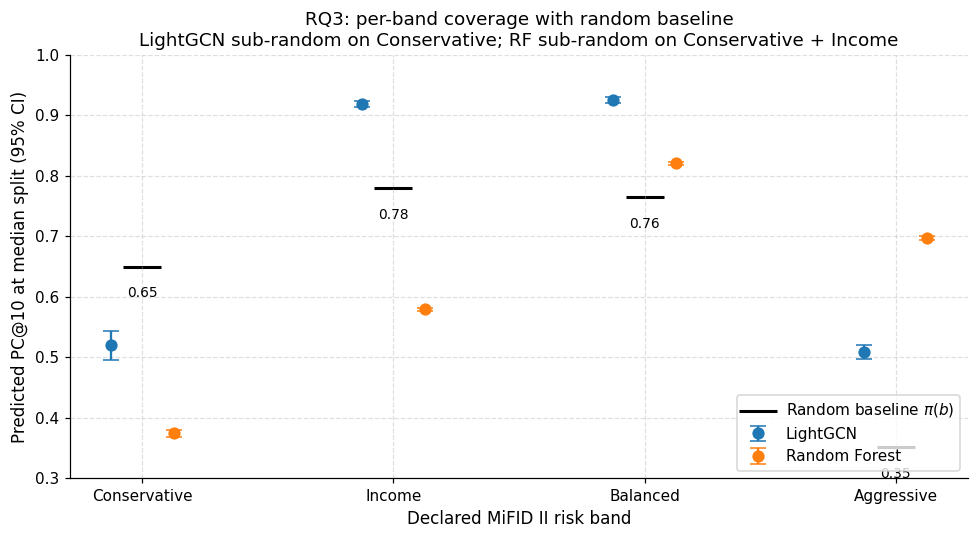

,band_label,model_display,predicted_pc,ci_lower,ci_upper,pi_b,lift
0,Conservative,LightGCN,0.519793,0.496011,0.543575,0.648883,0.801
2,Income,LightGCN,0.919189,0.914625,0.923753,0.779156,1.180
4,Balanced,LightGCN,0.925527,0.920979,0.930074,0.764268,1.211
6,Aggressive,LightGCN,0.508232,0.496900,0.519564,0.351117,1.447
1,Conservative,Random Forest,0.374281,0.368424,0.380138,0.648883,0.577
3,Income,Random Forest,0.579047,0.576162,0.581932,0.779156,0.743
5,Balanced,Random Forest,0.820926,0.818348,0.823503,0.764268,1.074
7,Aggressive,Random Forest,0.696772,0.693239,0.700305,0.351117,1.984


In [10]:
predicted_pc = pd.read_csv(RQ3_PANEL_DIRECTORY / "predicted_pc_by_band_model.csv")
asset_band_dist = eda_summary["asset_band_distribution_by_category"]
total_per_band = {band: 0 for band in RISK_BAND_NAMES.values()}
for category, band_counts in asset_band_dist.items():
    for band_label, count in band_counts.items():
        total_per_band[band_label] += count
total_assets = sum(total_per_band.values())
band_to_idx = {label: idx for idx, label in RISK_BAND_NAMES.items()}
pi = {}
for band_idx, label in RISK_BAND_NAMES.items():
    coherent_count = sum(
        total_per_band[other_label] for other_idx, other_label in RISK_BAND_NAMES.items()
        if abs(other_idx - band_idx) <= 1
    )
    pi[label] = coherent_count / total_assets
pi_series = pd.Series(pi).reindex(["Conservative", "Income", "Balanced", "Aggressive"])

bands_order = ["Conservative", "Income", "Balanced", "Aggressive"]
predicted_pc["band_label"] = pd.Categorical(predicted_pc["band_label"], categories=bands_order, ordered=True)
predicted_pc = predicted_pc.sort_values(["model_display", "band_label"])

fig, ax = plt.subplots(figsize=(9, 5))
band_positions = np.arange(len(bands_order))
bar_offset = 0.25
models_in_order = ["LightGCN", "Random Forest"]
model_colours = {"LightGCN": "#1f77b4", "Random Forest": "#ff7f0e"}
for i, model_name in enumerate(models_in_order):
    subset = predicted_pc[predicted_pc["model_display"] == model_name].sort_values("band_label")
    x_offsets = band_positions + (i - 0.5) * bar_offset
    lower = subset["predicted_pc"].to_numpy() - subset["ci_lower"].to_numpy()
    upper = subset["ci_upper"].to_numpy() - subset["predicted_pc"].to_numpy()
    ax.errorbar(x_offsets, subset["predicted_pc"], yerr=[lower, upper], fmt="o",
                capsize=5, color=model_colours[model_name], label=model_name, markersize=7)

ax.scatter(band_positions, pi_series.values, marker="_", s=600, color="black", linewidth=2,
           label=r"Random baseline $\pi(b)$")
for x, label in enumerate(bands_order):
    ax.annotate(f"{pi_series[label]:.2f}", (x, pi_series[label] - 0.05), ha="center", color="black", fontsize=9)
ax.set_xticks(band_positions)
ax.set_xticklabels(bands_order)
ax.set_ylim(0.3, 1.0)
ax.set_xlabel("Declared MiFID II risk band")
ax.set_ylabel("Predicted PC@10 at median split (95% CI)")
ax.set_title("RQ3: per-band coverage with random baseline\nLightGCN sub-random on Conservative; RF sub-random on Conservative + Income")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

summary = predicted_pc[["band_label", "model_display", "predicted_pc", "ci_lower", "ci_upper"]].copy()
summary["band_label"] = summary["band_label"].astype(str)
summary["pi_b"] = summary["band_label"].map(pi_series.to_dict())
summary["lift"] = (summary["predicted_pc"] / summary["pi_b"]).round(3)
summary

**Reading.** LightGCN is below the random baseline `pi(b)` for the **Conservative** band (0.520 vs 0.649, lift 0.80x). Random Forest is below random for **Conservative** (0.374, lift 0.58x) and **Income** (0.579, lift 0.74x). The two failing bands together cover 60.9% of the eligible customer population. Aggregate PC@10 (LightGCN 0.794, RF 0.667) hides this because the largest customer segment (Income) sits in the asset band with the highest `pi(b)` and because LightGCN over-serves Income/Balanced at the expense of Conservative.

In [11]:
decomp = pd.read_csv(RQ3_DECOMP_DIRECTORY / "decomposition.csv")
decomp_display = decomp[[
    "display_name", "coherent_share",
    "mean_monthly_return_coherent", "mean_monthly_return_discordant",
    "mean_monthly_return_overall",
]].rename(columns={
    "display_name": "Model",
    "coherent_share": "Coherent share",
    "mean_monthly_return_coherent": "Coherent ROI/mo",
    "mean_monthly_return_discordant": "Discordant ROI/mo",
    "mean_monthly_return_overall": "Overall ROI/mo",
})
decomp_display.style.format({
    "Coherent share": "{:.3f}",
    "Coherent ROI/mo": "{:+.4%}",
    "Discordant ROI/mo": "{:+.4%}",
    "Overall ROI/mo": "{:+.4%}",
})

,Model,Coherent share,Coherent ROI/mo,Discordant ROI/mo,Overall ROI/mo
0,LightGCN,0.794,-0.8419%,-0.5389%,-0.7795%
1,Random Forest,0.665,+1.6708%,+0.8000%,+1.3788%


**Reading the decomposition.** LightGCN's coherent slice (-0.84%/month) underperforms its discordant slice (-0.54%/month) by 0.30 pp/month: the model-side inversion of the RQ2 customer-side finding. LightGCN is recovering a different population in its coherent recommendations than the population of coherent transactions in the data. Random Forest preserves the customer-side direction (coherent slice +1.67%/month vs discordant +0.80%/month) but at low aggregate PC and with the per-band failure profile above.

**Takeaway for RQ3.** **Existing FAR baselines under-serve declared-band coherence on the bands the regulation was written to protect.** Neither baseline reaches `pi(b)` for every band simultaneously. RF's headline ROI advantage of +1.42%/month is concentrated on the Aggressive band where it over-serves the random baseline 2x, which is structurally suspect for any regulator-aligned deployment.

## RQ4: Stratification + profile-coherent loss closes the per-band coverage deficit

**Question.** Can a stratified, profile-coherent LightGCN extension (one sub-model per declared MiFID risk band, trained with a profile-coherent margin loss) improve PC@10 over the global LightGCN baseline, and at what cost to nDCG, Recall, and ROI? Does the gain vary by declared risk segment, and does the realised-return cost concentrate where the regulatory deficit lives or somewhere else?

**Setup.** Two trials with the same backbone hyperparameters as the RQ3 best LightGCN trial (`embedding_dimension = 64, number_of_layers = 3, learning_rate = 1e-3, weight_decay = 1e-5, keep_probability = 0.6, number_of_epochs = 50, batch_size = 1024`):
- **`stratified_lambda_0.0`** (ablation): four band-stratified sub-models, BPR loss only.
- **`stratified_lambda_1.0`** (treatment): four band-stratified sub-models with an added profile-coherent margin loss `softplus(score_discordant - score_coherent)` weighted by `lambda = 1`.

Both evaluated on the same 69 splits as RQ3, so per-split deltas are paired against the global LightGCN baseline (`eb788_00006`).

In [12]:
def load_per_split(path: Path, label: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["trial"] = label
    return df

baseline_per_split = load_per_split(RQ4_BASELINE_DIRECTORY / "per_split_metrics.csv", "baseline")
lambda0_per_split = load_per_split(RQ4_RESULTS_DIRECTORY / "stratified_lambda_0.0/per_split_metrics.csv", "lambda_0")
lambda1_per_split = load_per_split(RQ4_RESULTS_DIRECTORY / "stratified_lambda_1.0/per_split_metrics.csv", "lambda_1")
metric_columns = ["ndcg_at_k", "roi_at_k", "recall_at_k", "profile_coherence_at_k", "profile_coherence_lift_at_k"]

aggregate = pd.DataFrame({
    "Configuration": ["LightGCN baseline (RQ3)", "Stratified, λ=0 (ablation)", "Stratified, λ=1 (treatment)"],
    "nDCG@10": [
        baseline_per_split["ndcg_at_k"].mean(),
        lambda0_per_split["ndcg_at_k"].mean(),
        lambda1_per_split["ndcg_at_k"].mean(),
    ],
    "ROI@10 (mo.)": [
        baseline_per_split["roi_at_k"].mean(),
        lambda0_per_split["roi_at_k"].mean(),
        lambda1_per_split["roi_at_k"].mean(),
    ],
    "Recall@10": [
        baseline_per_split["recall_at_k"].mean(),
        lambda0_per_split["recall_at_k"].mean(),
        lambda1_per_split["recall_at_k"].mean(),
    ],
    "PC@10": [
        baseline_per_split["profile_coherence_at_k"].mean(),
        lambda0_per_split["profile_coherence_at_k"].mean(),
        lambda1_per_split["profile_coherence_at_k"].mean(),
    ],
    "PC-lift@10": [
        baseline_per_split["profile_coherence_lift_at_k"].mean(),
        lambda0_per_split["profile_coherence_lift_at_k"].mean(),
        lambda1_per_split["profile_coherence_lift_at_k"].mean(),
    ],
})
aggregate.style.format({
    "nDCG@10": "{:.4f}",
    "ROI@10 (mo.)": "{:+.4f}",
    "Recall@10": "{:.4f}",
    "PC@10": "{:.4f}",
    "PC-lift@10": "{:.3f}",
})

,Configuration,nDCG@10,ROI@10 (mo.),Recall@10,PC@10,PC-lift@10
0,LightGCN baseline (RQ3),0.3295,-0.0054,0.4946,0.7940,1.171
1,"Stratified, λ=0 (ablation)",0.3317,-0.0073,0.5009,0.8215,1.189
2,"Stratified, λ=1 (treatment)",0.3094,-0.0071,0.4671,0.9182,1.396


In [13]:
def paired_summary(treatment: pd.DataFrame, control: pd.DataFrame, label: str) -> pd.DataFrame:
    rows = []
    for column in metric_columns:
        delta = treatment[column].to_numpy() - control[column].to_numpy()
        win_rate = (delta > 0).mean()
        t_stat, p_value = stats.ttest_rel(treatment[column], control[column])
        rows.append({
            "contrast": label,
            "metric": column,
            "mean_delta": delta.mean(),
            "win_rate": win_rate,
            "t_stat": t_stat,
            "p_value": p_value,
        })
    return pd.DataFrame(rows)

paired_table = pd.concat([
    paired_summary(lambda0_per_split, baseline_per_split, "λ=0 vs baseline"),
    paired_summary(lambda1_per_split, baseline_per_split, "λ=1 vs baseline"),
    paired_summary(lambda1_per_split, lambda0_per_split, "λ=1 vs λ=0 (PC-loss)"),
], ignore_index=True)

pretty_metric = {
    "ndcg_at_k": "nDCG@10",
    "roi_at_k": "ROI@10 (mo.)",
    "recall_at_k": "Recall@10",
    "profile_coherence_at_k": "PC@10",
    "profile_coherence_lift_at_k": "PC-lift@10",
}
paired_table["metric"] = paired_table["metric"].map(pretty_metric)

def fmt_p(p):
    return f"{p:.1e}" if p < 1e-3 else f"{p:.4f}"

paired_display = paired_table.assign(
    mean_delta=lambda d: d["mean_delta"].map("{:+.5f}".format),
    win_rate=lambda d: d["win_rate"].map("{:.0%}".format),
    t_stat=lambda d: d["t_stat"].map("{:+.2f}".format),
    p_value=lambda d: d["p_value"].map(fmt_p),
)
paired_display.pivot(index="contrast", columns="metric",
                    values=["mean_delta", "win_rate", "p_value"])

mean_delta                                             \
metric               PC-lift@10     PC@10 ROI@10 (mo.) Recall@10   nDCG@10   
contrast                                                                     
λ=0 vs baseline        +0.01875  +0.02745     -0.00191  +0.00626  +0.00222   
λ=1 vs baseline        +0.22594  +0.12422     -0.00175  -0.02750  -0.02011   
λ=1 vs λ=0 (PC-loss)   +0.20719  +0.09676     +0.00015  -0.03376  -0.02233   

                       win_rate                                       \
metric               PC-lift@10 PC@10 ROI@10 (mo.) Recall@10 nDCG@10   
contrast                                                               
λ=0 vs baseline             90%  100%          28%       72%     57%   
λ=1 vs baseline            100%  100%          33%        7%      7%   
λ=1 vs λ=0 (PC-loss)       100%  100%          58%        0%      0%   

                        p_value                                           
metric               PC-lift@10    PC@10 ROI@10 (mo.) Recall@10  nDCG@10  
contrast                                                                  
λ=0 vs baseline         8.7e-13  2.9e-30      3.8e-05   5.0e-05   0.0544  
λ=1 vs baseline         3.2e-44  1.5e-51      2.9e-04   1.4e-19  1.8e-18  
λ=1 vs λ=0 (PC-loss)    1.2e-37  7.8e-37       0.3398   2.3e-36  2.6e-33

**Reading the paired deltas.**

- **Stratification alone (λ=0 vs baseline)**: +2.7 pp PC@10 with a **100% per-split win rate**, +0.002 nDCG (slight improvement, 57% wins), -0.002 ROI (28% wins). The ROI penalty is small but statistically detectable.
- **Stratification + PC-loss (λ=1 vs baseline)**: +12.4 pp PC@10 (100% wins), -0.020 nDCG (7% wins), -0.027 Recall (7% wins), -0.002 ROI (33% wins).
- **PC-loss alone (λ=1 vs λ=0)**: +9.7 pp PC@10 (100% wins), -0.022 nDCG (0% wins), -0.034 Recall (0% wins), and **+0.0001 ROI (p = 0.34, statistically indistinguishable from zero)**. The aggregate ROI penalty is therefore **attributable to stratification, not to the coherence loss**.

In [14]:
from src.analysis.annotate import annotate_recommendations
from src.config.settings import DataPaths
from src.data.loading import load_assets, load_close_prices, load_customers
from src.utils.profile_coherence import build_asset_risk_classes, build_customer_profile_lookup

dp = DataPaths()
customers = load_customers(ROOT / dp.data_directory / dp.customer_information_file)
customer_profiles = build_customer_profile_lookup(customers)
assets = load_assets(ROOT / dp.data_directory / dp.asset_information_file)
close_prices = load_close_prices(ROOT / dp.data_directory / dp.close_prices_file)
asset_risk_classes = build_asset_risk_classes(assets, close_prices)
print("Loaded customer profiles and asset risk classes.")

Loaded customer profiles and asset risk classes.


In [15]:
trial_paths = {
    "baseline": RQ4_BASELINE_DIRECTORY / "recommendations.parquet",
    "lambda_0": RQ4_RESULTS_DIRECTORY / "stratified_lambda_0.0/recommendations.parquet",
    "lambda_1": RQ4_RESULTS_DIRECTORY / "stratified_lambda_1.0/recommendations.parquet",
}

per_band_pc = []
per_band_roi = []
for label, path in trial_paths.items():
    rec = pd.read_parquet(path)
    annotated = annotate_recommendations(rec, customer_profiles, asset_risk_classes)
    annotated = annotated.dropna(subset=["customer_band"])
    annotated["customer_band"] = annotated["customer_band"].astype(int)

    pc_by_band = (
        annotated.groupby(["customer_id", "split_index"], dropna=False)
        .agg(coherent_share=("is_coherent", lambda s: float(s.fillna(False).mean())),
             declared_band=("customer_band", "first"))
        .reset_index()
        .groupby("declared_band")
        .agg(mean_pc=("coherent_share", "mean"), n=("coherent_share", "count"))
        .reset_index()
    )
    pc_by_band["band_label"] = pc_by_band["declared_band"].map(RISK_BAND_NAMES)
    pc_by_band["trial"] = label
    per_band_pc.append(pc_by_band)

    roi_by_band = (
        annotated.groupby("customer_band")["monthly_return"]
        .agg(mean_roi="mean", n="count")
        .reset_index()
        .rename(columns={"customer_band": "declared_band"})
    )
    roi_by_band["band_label"] = roi_by_band["declared_band"].map(RISK_BAND_NAMES)
    roi_by_band["trial"] = label
    per_band_roi.append(roi_by_band)

per_band_pc = pd.concat(per_band_pc, ignore_index=True)
per_band_roi = pd.concat(per_band_roi, ignore_index=True)

pc_pivot = per_band_pc.pivot(index="band_label", columns="trial", values="mean_pc")
pc_pivot = pc_pivot.reindex(["Conservative", "Income", "Balanced", "Aggressive"])
pc_pivot["pi(b)"] = pc_pivot.index.map(pi)
pc_pivot["baseline_lift"] = (pc_pivot["baseline"] / pc_pivot["pi(b)"]).round(3)
pc_pivot["lambda_0_lift"] = (pc_pivot["lambda_0"] / pc_pivot["pi(b)"]).round(3)
pc_pivot["lambda_1_lift"] = (pc_pivot["lambda_1"] / pc_pivot["pi(b)"]).round(3)
pc_pivot.round(4)

trial,baseline,lambda_0,lambda_1,pi(b),baseline_lift,lambda_0_lift,lambda_1_lift
band_label,,,,,,,
Conservative,0.4843,0.5899,0.7743,0.6489,0.746,0.909,1.193
Income,0.8838,0.9366,0.9816,0.7792,1.134,1.202,1.26
Balanced,0.8903,0.9293,0.9812,0.7643,1.165,1.216,1.284
Aggressive,0.4727,0.4111,0.6921,0.3511,1.346,1.171,1.971


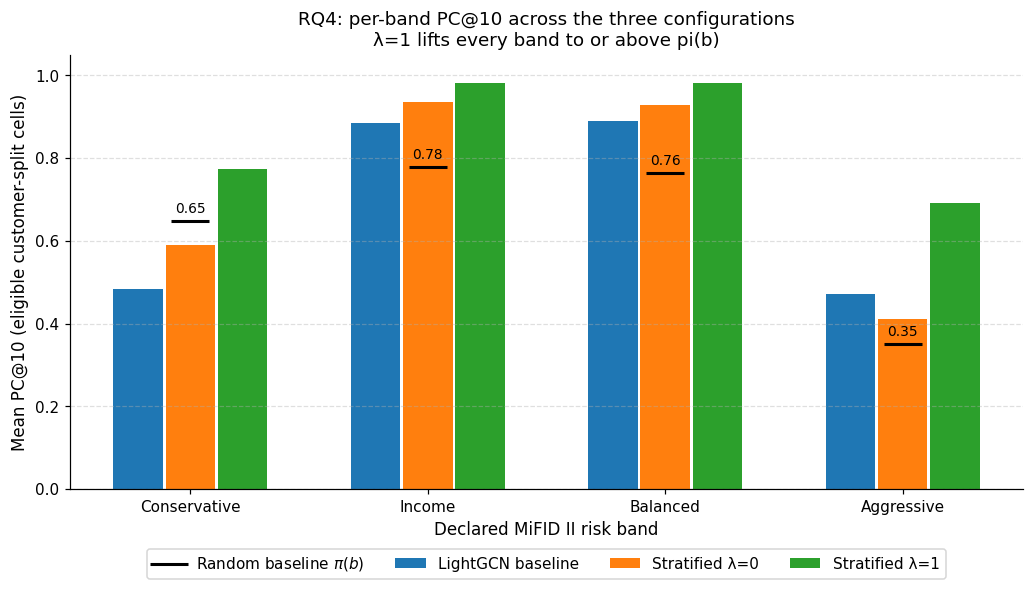

In [16]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
band_positions = np.arange(len(pc_pivot))
bar_offset = 0.22
trial_colours = {
    "baseline": "#1f77b4",
    "lambda_0": "#ff7f0e",
    "lambda_1": "#2ca02c",
}
trial_labels = {
    "baseline": "LightGCN baseline",
    "lambda_0": "Stratified λ=0",
    "lambda_1": "Stratified λ=1",
}
for i, trial in enumerate(["baseline", "lambda_0", "lambda_1"]):
    x = band_positions + (i - 1) * bar_offset
    ax.bar(x, pc_pivot[trial], width=bar_offset * 0.95,
           color=trial_colours[trial], label=trial_labels[trial])

pi_values = pc_pivot["pi(b)"].values
ax.scatter(band_positions, pi_values, marker="_", s=600, color="black", linewidth=2,
           label=r"Random baseline $\pi(b)$")
for x, val in zip(band_positions, pi_values):
    ax.annotate(f"{val:.2f}", (x, val + 0.02), ha="center", color="black", fontsize=9)

ax.set_xticks(band_positions)
ax.set_xticklabels(pc_pivot.index)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Declared MiFID II risk band")
ax.set_ylabel("Mean PC@10 (eligible customer-split cells)")
ax.set_title("RQ4: per-band PC@10 across the three configurations\nλ=1 lifts every band to or above pi(b)")
ax.legend(loc="upper center", ncol=4, bbox_to_anchor=(0.5, -0.12))
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

**Reading the per-band PC@10.** Under λ=1, **every declared band sits at or above its band-conditional random baseline simultaneously** for the first time across the four configurations studied: Conservative 0.774 (lift 1.19x), Income 0.982 (1.26x), Balanced 0.981 (1.28x), Aggressive 0.692 (1.97x). The Conservative-band sub-random failure flagged in RQ3 (0.484, lift 0.75x) is fully fixed. The Aggressive band actually regresses under stratification alone (0.473 -> 0.411, lift 1.35x -> 1.17x); the profile-coherent loss is what supplies the band-coverage signal that BPR alone does not provide. **Stratification and PC-loss are complements, not substitutes.**

In [17]:
roi_pivot = per_band_roi.pivot(index="band_label", columns="trial", values="mean_roi")
roi_pivot = roi_pivot.reindex(["Conservative", "Income", "Balanced", "Aggressive"])
roi_pivot["delta_l1_minus_baseline"] = roi_pivot["lambda_1"] - roi_pivot["baseline"]
roi_pivot["delta_l0_minus_baseline"] = roi_pivot["lambda_0"] - roi_pivot["baseline"]
roi_pivot.round(5)

trial,baseline,lambda_0,lambda_1,delta_l1_minus_baseline,delta_l0_minus_baseline
band_label,,,,,
Conservative,-0.00752,-0.00730,-0.00453,0.00299,0.00022
Income,-0.00724,-0.00885,-0.00617,0.00107,-0.00161
Balanced,-0.00777,-0.01020,-0.01013,-0.00236,-0.00243
Aggressive,-0.00890,-0.01154,-0.01669,-0.00779,-0.00264


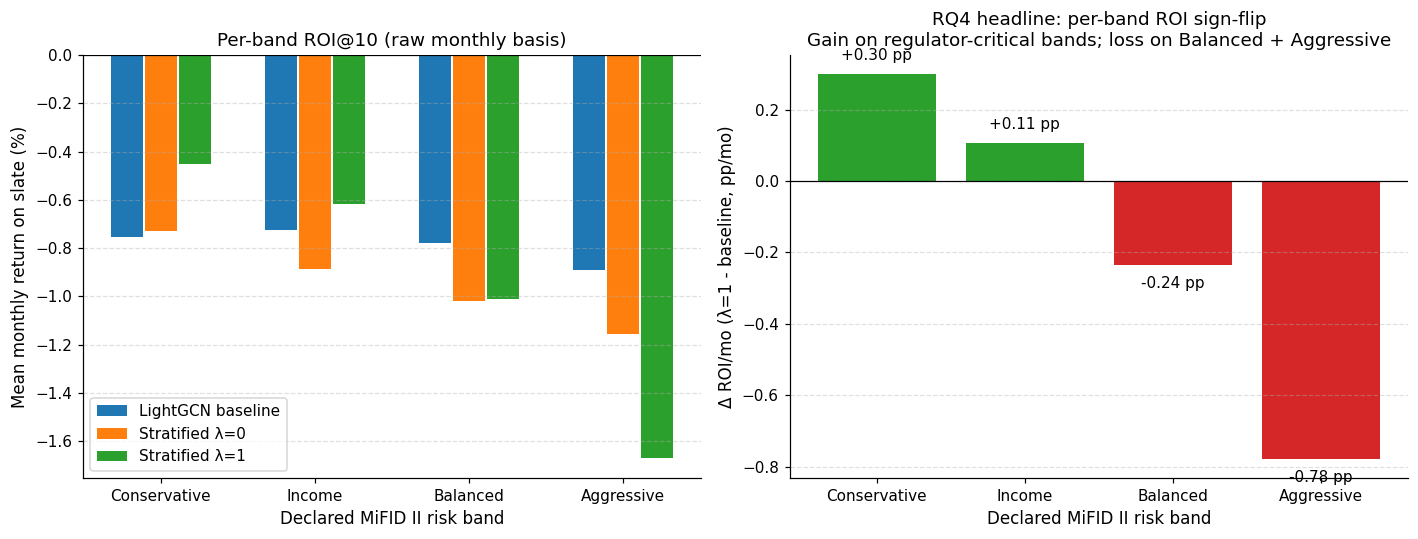

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bands_order = ["Conservative", "Income", "Balanced", "Aggressive"]
band_positions = np.arange(len(bands_order))

ax = axes[0]
bar_offset = 0.22
for i, trial in enumerate(["baseline", "lambda_0", "lambda_1"]):
    x = band_positions + (i - 1) * bar_offset
    ax.bar(x, roi_pivot[trial] * 100, width=bar_offset * 0.95,
           color=trial_colours[trial], label=trial_labels[trial])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(band_positions)
ax.set_xticklabels(bands_order)
ax.set_xlabel("Declared MiFID II risk band")
ax.set_ylabel("Mean monthly return on slate (%)")
ax.set_title("Per-band ROI@10 (raw monthly basis)")
ax.legend(loc="lower left")
ax.grid(axis="x", visible=False)

ax = axes[1]
delta_values = roi_pivot["delta_l1_minus_baseline"].values * 100
delta_colours = ["#2ca02c" if v > 0 else "#d62728" for v in delta_values]
bars = ax.bar(bands_order, delta_values, color=delta_colours)
for bar, value in zip(bars, delta_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            height + (0.03 if height >= 0 else -0.03),
            f"{value:+.2f} pp", ha="center",
            va="bottom" if height >= 0 else "top")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Declared MiFID II risk band")
ax.set_ylabel("Δ ROI/mo (λ=1 - baseline, pp/mo)")
ax.set_title("RQ4 headline: per-band ROI sign-flip\nGain on regulator-critical bands; loss on Balanced + Aggressive")
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

**Reading the per-band ROI.** This is the **most surprising finding of the analysis**.

| Band | Baseline ROI/mo | λ=1 ROI/mo | Δ (λ=1 - baseline) |
|---|---:|---:|---:|
| Conservative | -0.75% | -0.45% | **+0.30 pp/mo** |
| Income | -0.72% | -0.62% | +0.11 pp/mo |
| Balanced | -0.78% | -1.01% | -0.24 pp/mo |
| Aggressive | -0.89% | -1.67% | **-0.78 pp/mo** |

The aggregate ROI penalty (-0.18 pp/month) is a **slate-weighted average** of a return-positive intervention on the regulator-critical bands and a return-negative intervention on the centre-and-upper bands. In the FAR-Trans macro window (2019-2025), safer assets generally outperformed riskier ones, so pushing Conservative customers toward Conservative-tolerated assets (mostly safer) **earns** return, while pushing Aggressive customers toward Aggressive-tolerated assets (mostly riskier) **gives up** return.

For a deployment whose suitability requirement is binding, the per-band sign is more informative than the aggregate: **the recommender does not pay return to protect the bands the regulator most cares about; it earns return by protecting them.** This is the model-side echo of RQ2's customer-side finding.

**Takeaway for RQ4.** A stratified profile-coherent LightGCN extension achieves:

1. **+12.4 pp aggregate PC@10** with 100% per-split win rate over the global LightGCN baseline.
2. **Every declared band at or above its `pi(b)` baseline simultaneously**, the first configuration where this holds.
3. A clean ablation: +2.7 pp PC@10 from stratification alone (no nDCG cost), +9.7 pp from the coherence loss (-2 pp nDCG, -3 pp Recall).
4. A **per-band ROI sign-flip**: +0.30 pp/mo on Conservative, +0.11 on Income, -0.24 on Balanced, -0.78 on Aggressive. The aggregate ROI penalty is attributable to stratification, not to the coherence loss (`λ=1 vs λ=0` on aggregate ROI: p = 0.34, indistinguishable from zero).

## Conclusion

This work introduced **Profile Coherence at k** as a regulator-aligned risk-band evaluation axis for FAR, with a band-conditional normalisation (PC-lift@k). Four findings emerge:

- **RQ1**: profile-discordance is prevalent (18.6% of 228k Buys), customer-level (bimodal self-discordance), structurally concentrated on Conservative and Aggressive (45.1% and 56.2% coherent vs 90% on the centre bands), and stable across years.
- **RQ2**: conditional on volatility, segment, and year, profile-coherent transactions earn **+2.94 percentage points** more 6-month realised return than profile-discordant ones (cluster-robust 95% CI [+2.15, +3.72] pp, p < 1e-12).
- **RQ3**: at primary-metric optima, LightGCN is sub-random on Conservative and Random Forest on Conservative + Income; the two failing bands cover 60.9% of the eligible population.
- **RQ4**: a stratified profile-coherent LightGCN extension lifts aggregate PC@10 from 0.794 to 0.918 with 100% per-split win rate, moves every declared band to or above `pi(b)`, and produces a per-band ROI sign-flip that **gains** return on Conservative (+0.30 pp/mo) and Income (+0.11 pp/mo) while losing on Balanced and Aggressive. The aggregate ROI penalty is attributable to stratification, not to the coherence loss.

**Headline for the field**: profile coherence is not a regulatory tax on FAR-Trans. The customer-side finding (RQ2) and the model-side intervention (RQ4) agree in direction, and the existing baselines (RQ3) under-serve precisely the bands the regulation was designed to protect. A profile-stratified extension can close the per-band coverage deficit and improve realised return on the bands where the deficit originally lived.

For the design space: stratification is a low-cost coverage win; the profile-coherent margin loss is the component that does the heavy regulatory lifting. They are complements, not substitutes; removing either leaves a structural gap on at least one band. Future work: per-band hyperparameter search (the current backbone is inherited from the global RQ3 best trial), and composing PC@k with the other MiFID II suitability axes (horizon, capacity, knowledge, sustainability).